# SG Job Data — Exploratory Data Analysis

This notebook explores the raw `SGJobData.csv` to understand data quality and inform the cleaning pipeline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../SGJobData.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head(3)

Shape: (1048585, 22)


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,0,1,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,2,2,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,3,1,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0


## 1. Shape & Types

In [3]:
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary                    


Memory usage: 874.0 MB


## 2. Missing Values

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"count": missing, "pct": missing_pct})[missing > 0]

,count,pct
occupationId,1048585,100.00
categories,3988,0.38
metadata_expiryDate,3988,0.38
metadata_jobPostId,3988,0.38
metadata_newPostingDate,3988,0.38
employmentTypes,3988,0.38
status_jobStatus,3988,0.38
metadata_originalPostingDate,3988,0.38
positionLevels,3988,0.38
postedCompany_name,3988,0.38


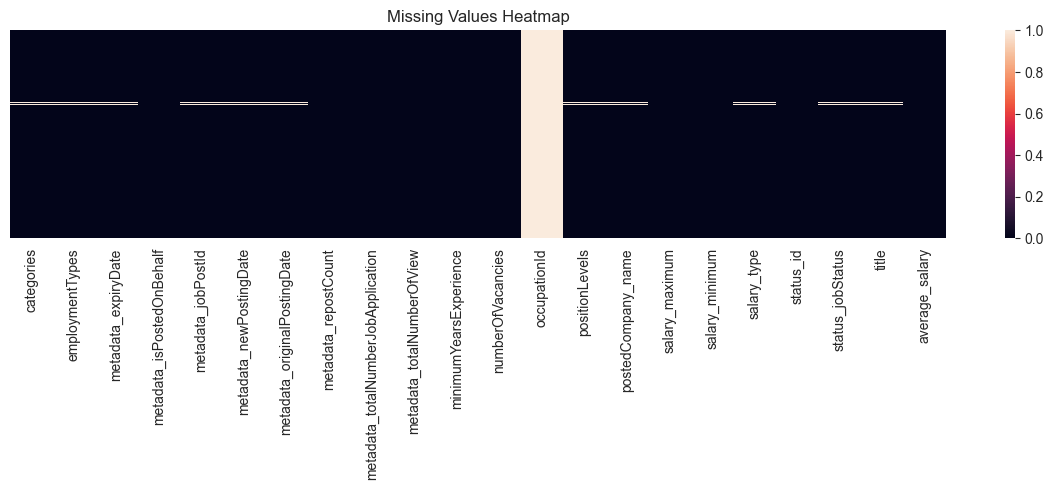

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, ax=ax)
ax.set_title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

## 3. Duplicates

In [6]:
dup_count = df["metadata_jobPostId"].duplicated().sum()
print(f"Duplicate job post IDs: {dup_count} ({dup_count / len(df) * 100:.2f}%)")

Duplicate job post IDs: 3987 (0.38%)


## 4. Categories Column

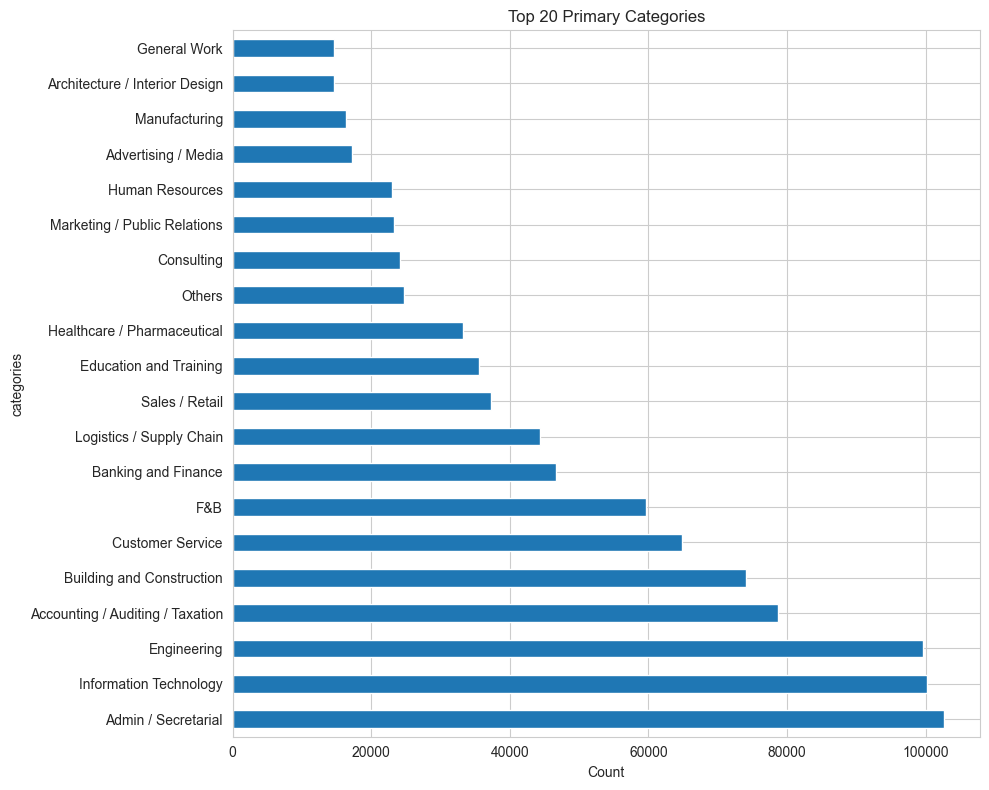


Null categories after parsing: 3988
Unique categories: 43


In [7]:
def parse_primary_category(cat_str):
    try:
        cats = json.loads(cat_str)
        return cats[0]["category"] if cats else None
    except (json.JSONDecodeError, TypeError, KeyError, IndexError):
        return None

cats = df["categories"].apply(parse_primary_category)
cat_counts = cats.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 8))
cat_counts.plot.barh(ax=ax)
ax.set_title("Top 20 Primary Categories")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

print(f"\nNull categories after parsing: {cats.isnull().sum()}")
print(f"Unique categories: {cats.nunique()}")

## 5. Salary Analysis

In [8]:
print("Salary type distribution:")
print(df["salary_type"].value_counts())

print(f"\nRows where both salary_min and salary_max are 0: {((df['salary_minimum'] == 0) & (df['salary_maximum'] == 0)).sum()}")
print(f"Rows where salary_min > salary_max: {(df['salary_minimum'] > df['salary_maximum']).sum()}")

Salary type distribution:
salary_type
Monthly    1044597
Name: count, dtype: int64

Rows where both salary_min and salary_max are 0: 3988
Rows where salary_min > salary_max: 0


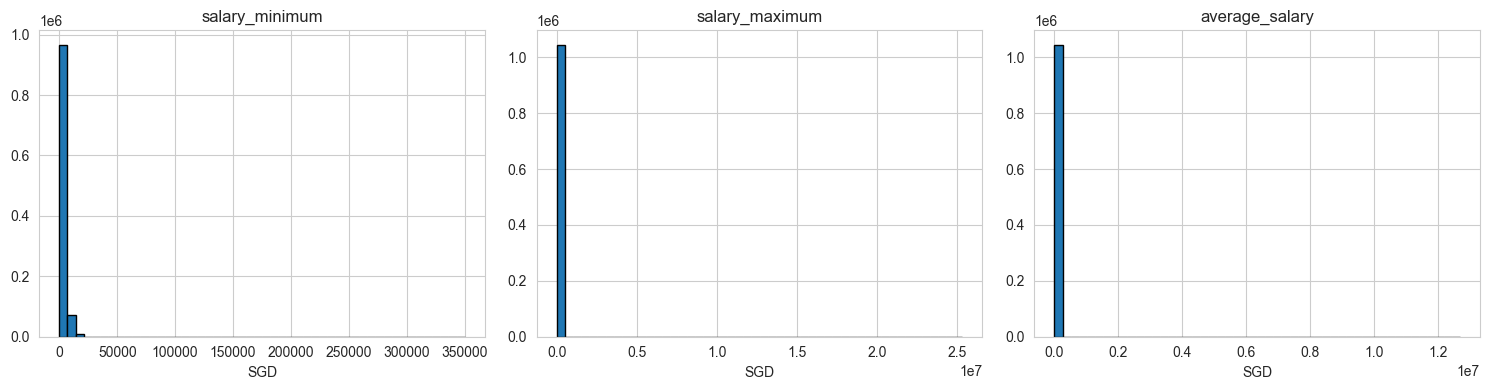


Salary stats (non-zero):


,salary_minimum,salary_maximum,average_salary
count,1.044597e+06,1.044597e+06,1.044597e+06
mean,3.829878e+03,5.745429e+03,4.787654e+03
std,3.169443e+03,5.027833e+04,2.552497e+04
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,2.500000e+03,3.300000e+03,2.900000e+03
50%,3.000000e+03,4.500000e+03,3.800000e+03
75%,4.500000e+03,6.500000e+03,5.500000e+03
max,3.500000e+05,2.533000e+07,1.266640e+07


In [9]:
valid_sal = df[(df["salary_minimum"] > 0) | (df["salary_maximum"] > 0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(["salary_minimum", "salary_maximum", "average_salary"]):
    axes[i].hist(valid_sal[col].dropna(), bins=50, edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("SGD")
plt.tight_layout()
plt.show()

print("\nSalary stats (non-zero):")
valid_sal[["salary_minimum", "salary_maximum", "average_salary"]].describe()

In [10]:
p99 = valid_sal["average_salary"].quantile(0.99)
print(f"99th percentile of average_salary: {p99:.0f}")
print(f"Max average_salary: {valid_sal['average_salary'].max():.0f}")
print(f"Rows above 99th pct: {(valid_sal['average_salary'] > p99).sum()}")

99th percentile of average_salary: 16750
Max average_salary: 12666400
Rows above 99th pct: 10404


## 6. Date Fields

In [11]:
for col in ["metadata_newPostingDate", "metadata_expiryDate", "metadata_originalPostingDate"]:
    parsed = pd.to_datetime(df[col], errors="coerce")
    invalid = parsed.isnull().sum() - df[col].isnull().sum()
    print(f"{col}: range [{parsed.min()} — {parsed.max()}], invalid parses: {invalid}")

metadata_newPostingDate: range [2023-02-24 00:00:00 — 2024-05-29 00:00:00], invalid parses: 0


metadata_expiryDate: range [2023-04-04 00:00:00 — 2024-12-12 00:00:00], invalid parses: 0


metadata_originalPostingDate: range [2022-10-03 00:00:00 — 2024-05-29 00:00:00], invalid parses: 0


## 7. Text Fields

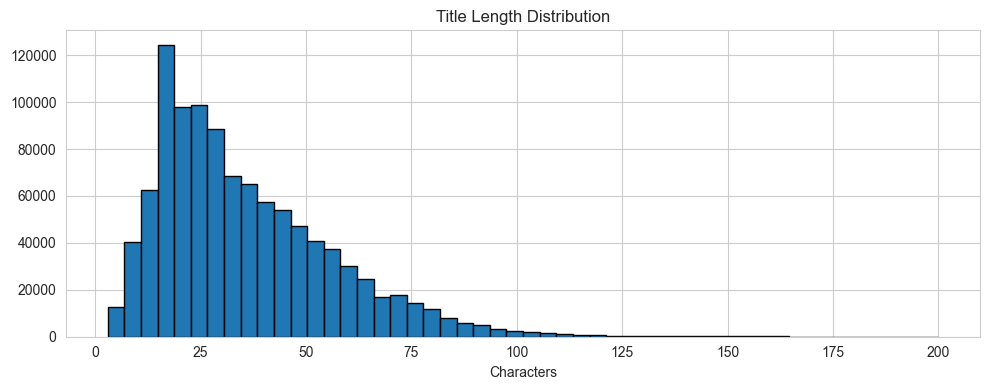

Unique companies: 53151

Sample company names (first 10):
postedCompany_name
THE SUPREME HR ADVISORY PTE. LTD.    61638
RECRUITPEDIA PTE. LTD.               50444
RECRUIT EXPRESS PTE LTD              33170
ANRADUS PTE. LTD.                    25805
RECRUIT EXPERT PTE. LTD.             21608
PERSOLKELLY SINGAPORE PTE. LTD.      13153
TALENT TRADER GROUP PTE. LTD.         8429
RK RECRUITMENT PTE. LTD.              8178
RECRUIT LYNC PTE. LTD.                5901
HYPERSCAL SOLUTIONS PTE. LTD.         5874
Name: count, dtype: int64


In [12]:
title_lens = df["title"].str.len()
fig, ax = plt.subplots(figsize=(10, 4))
title_lens.hist(bins=50, ax=ax, edgecolor="black")
ax.set_title("Title Length Distribution")
ax.set_xlabel("Characters")
plt.tight_layout()
plt.show()

print(f"Unique companies: {df['postedCompany_name'].nunique()}")
print(f"\nSample company names (first 10):")
print(df["postedCompany_name"].value_counts().head(10))

## Summary of Cleaning Decisions

1. **Drop duplicates** by `metadata_jobPostId`
2. **Parse categories** JSON → extract primary category (first item's `category` field)
3. **Normalize salary**: drop rows where salary_min = 0 AND salary_max = 0; cap at 99th percentile
4. **Parse dates**: drop rows with invalid `metadata_newPostingDate`
5. **Fill missing**: `minimumYearsExperience` → 0, `numberOfVacancies` → 1
6. **Standardize company names**: strip whitespace, title-case
7. **Rename columns** to clean snake_case matching DB schema